## Examples: An introduction to Random Forests

#### In this notebook, we look at a specific ensemble learning technique, the random forest. This algorithm is the combination of multiple decision trees. We'll examine how we can implement these models in Python using the `sklearn` library and also how random forests contribute to understanding the importance of predictive variables within a dataset.

### Learning Objectives
#### - Understand how random forests differ from decision trees
#### - Understand the training process of random forests and how we can use them to make predictions
#### - Know how to build a random forest regression model
#### - Understand how to use random forests to assess predictive variable importance

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/Explore-AI/Public-Data/master/house_price_by_area.csv')
df.head()

,LotArea,SalePrice
0,138,1204000
1,145,1274000
2,152,1673000
3,152,1232000
4,152,1195600


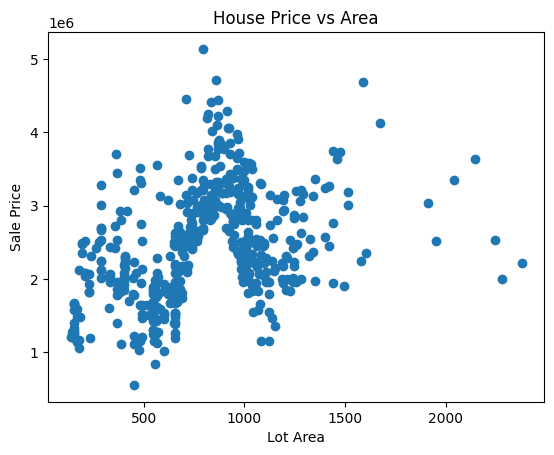

In [4]:
X = df['LotArea']
y = df['SalePrice']

plt.scatter(X, y)
plt.title('House Price vs Area')
plt.xlabel('Lot Area')
plt.ylabel('Sale Price')
plt.show()

In [5]:
type(X)

pandas.core.series.Series

### Preprocessing

In [6]:
# Standardise features
scaler = StandardScaler()

# Convert to numpy array first to apply np.newaxis
X_scaled = scaler.fit_transform(np.array(X)[:,np.newaxis])

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=6)

### Training

In [7]:
from sklearn.ensemble import RandomForestRegressor

RF = RandomForestRegressor(n_estimators=100, max_depth=5)
RF.fit(X_train, y_train)

RandomForestRegressor(max_depth=5)

### Testing

In [8]:
# Get predictions
y_pred = RF.predict(X_test)

# Compute RMSE
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

RMSE: 593596.0119910889


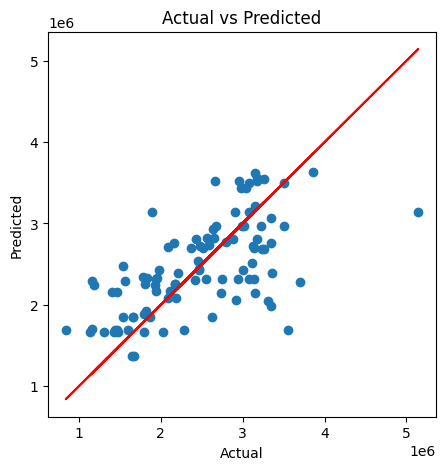

In [9]:
# Create figure and axes
f, ax = plt.subplots(figsize=(5,5))

# Plot actual vs. predicted values on axes
ax.set_title('Actual vs Predicted')
ax.set_xlabel('Actual')
ax.set_ylabel('Predicted')
ax.scatter(y_test, y_pred)
ax.plot(y_test, y_test, 'r')
plt.show()

### Tuning model hyperparameters

In [10]:
# 2 trees in forest
forest_1 = RandomForestRegressor(n_estimators=2, max_depth=5, random_state=23)

# 20 trees in forest
forest_2 = RandomForestRegressor(n_estimators=20, max_depth=5, random_state=23)

# 100 trees in forest
forest_3 = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=23)

In [11]:
forest_1.fit(X_train, y_train)

RandomForestRegressor(max_depth=5, n_estimators=2, random_state=23)

In [12]:
forest_2.fit(X_train, y_train)

RandomForestRegressor(max_depth=5, n_estimators=20, random_state=23)

In [13]:
forest_3.fit(X_train, y_train)

RandomForestRegressor(max_depth=5, random_state=23)

### Evaluate the models

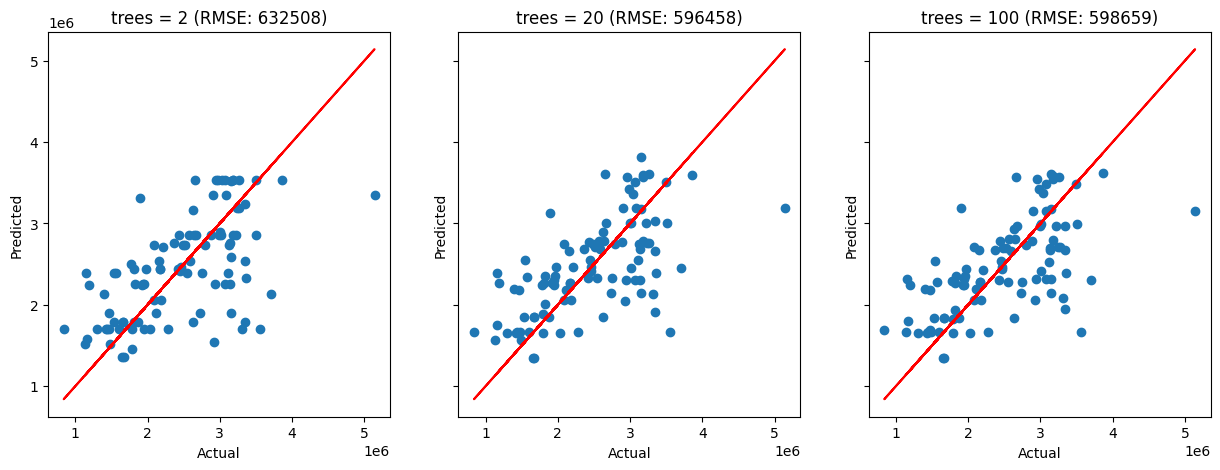

In [16]:
# Create figure and axes
f, ax = plt.subplots(figsize=(15,5), nrows=1, ncols=3, sharey=True)

# create list of titles and predictions to use in for loop
pred = [forest_1.predict(X_test), forest_2.predict(X_test), forest_3.predict(X_test)]
title = ['trees = 2', 'trees = 20', 'trees = 100']

# Loop through all axes to plot each model's results
for i in range(3):
    rmse = round(np.sqrt(mean_squared_error(pred[i], y_test)))
    ax[i].set_title(title[i] + " (RMSE: " + str(rmse)+ ")")
    ax[i].set_xlabel('Actual')
    ax[i].set_ylabel('Predicted')
    ax[i].plot(y_test, y_test, 'r')
    ax[i].scatter(y_test, pred[i])

In [19]:
RF.feature_importances_

array([1.])